# 🌿🔥 NDVI Fire-Susceptibility Feature Pipeline — GPU Accelerated
## Step 2: NDVI Novel Analysis — India (2000–2022)
### Reference: Biswas et al. (2025), *Environ. Sci. Pollut. Res.*, 32:4856–4878

**Extends:** Single raw NDVI → 9 NDVI-derived features
**Data:** MOD13A3.061, monthly 1km, NASA AppEEARS
**Study period:** 1 Nov 2000 – 15 Dec 2022 — **matches Step 1 exactly** (fire
points extraction), so every NDVI feature here is directly aligned, pixel and
month, with the real forest-fire points already extracted in Step 1.

---
### What changed vs. the previous version of this notebook

The previous version had several correctness and performance problems that
are fixed here:

| # | Problem in previous version | Fix in this version |
|---|---|---|
| 1 | Paths pointed to `C:\Users\...\Downloads\...` (wrong machine/folder) | Paths point to this project's actual local folders |
| 2 | `FIRE_CSV` and `BIO_ZONES` were referenced but **never defined** — those cells would crash on a fresh kernel | Both defined in Step 2 (Configuration), `FIRE_CSV` points at Step 1's real output |
| 3 | STL decomposition used a **per-pixel Python loop** calling `statsmodels.STL` — 12.7M pixels; the run crashed after 37 minutes at 6.7% complete (projected ≈9+ hours) | Replaced with a **GPU-vectorized classical 2×12 moving-average decomposition** applied to the whole `(T,H,W)` array at once — seconds, not hours |
| 4 | Mann-Kendall trend test used a **per-pixel `scipy.stats.kendalltau` double loop** (12.7M calls) — never even reached because STL crashed first | Replaced with a **GPU-vectorized Mann-Kendall S-statistic** computed via an O(T) lag-sweep across the whole grid simultaneously |
| 5 | CVSI's "optimal lag k\*" was chosen via a **proxy (temporal variance)** because fire data wasn't wired in — comment literally says *"using simulated fire mask for demo"* | k\* is now chosen by real **mutual information between CVSI and actual Step 1 fire occurrence** |
| 6 | NDVI–fire breakpoint threshold used a **synthetic proxy label** (`NDVI < 0.35`) instead of real fire data | Fit against **real fire/no-fire pixel labels** rasterized from Step 1's 541,545 extracted points, nationally and per biogeographic zone |
| 7 | QA/pixel-reliability files were discovered but **never actually applied** to mask unreliable pixels, despite Feature 1 being labelled "QA-Filtered NDVI" | QA masking is now genuinely applied (reliability ∈ {Good, Marginal} kept; Snow/Ice/Cloud/Fill dropped) |
| 8 | A dead, commented-out duplicate of the Moran's I cell was left in the notebook and errored on execution | Removed |
| 9 | No GPU usage anywhere — pure CPU NumPy for every array op | GPU-accelerated (CuPy, auto-detect with NumPy fallback) for anomaly/climatology, decomposition, Mann-Kendall, and CVSI — same auto-detect pattern as Step 1 |
| 10 | NDVI files spanned 2000-03 to 2025-12; processed regardless of Step 1's fire-data study period | Filtered to the exact Nov 2000 – Dec 2022 window (266 months, zero gaps) |
| 11 | **No India boundary masking at all** — the grid's spatial extent came purely from the raw NDVI GeoTIFFs' own raster bounds, so valid-NDVI pixels in neighbouring countries (Pakistan, Nepal, Bangladesh, Myanmar, Sri Lanka, Bhutan) were included in every feature | Dissolved `India_State_Boundary.shp` (reused from `LST_analysis/`, same convention as every other step) rasterized onto the NDVI grid and applied to `ndvi_stack` before any feature is computed |

### Novel contributions delivered by this step

| # | Feature | Basis | What makes it novel here |
|---|---|---|---|
| F1 | QA-filtered NDVI mean | pixel_reliability SDS | Genuinely QA-masked (not just claimed) |
| F2 | Climatological monthly mean | seasonal baseline, 2001–2020 | — |
| F3 | Monthly anomaly δ | δ = NDVI − μ̄⁽ᵐ⁾ | — |
| F4 / F5 | Trend + Residual decomposition | classical 2×12-MA, GPU-vectorized | Full-resolution, full-country decomposition that was **computationally infeasible** with the original per-pixel approach |
| F6 | Mann-Kendall τ (trend significance) | GPU lag-sweep S-statistic | Exact statistic at full 1km resolution nationwide, not a per-pixel serial loop |
| F7 | CVSI (pre-fire stress index) | optimal lag k\* | k\* chosen via **real mutual information with Step 1 fire points**, not a proxy |
| F8 | LISA cluster map | Local Moran's I | — |
| F9 | NDVI–fire breakpoint θ\* | piecewise logistic, national + zone-stratified | Fit on **real fire/no-fire labels** from Step 1, case-control balanced sampling |
| F10 | Fire occurrence raster | Step 1 points → NDVI grid | Makes the Step 1 → Step 2 link tangible and exportable |


## 📦 Step 0 — Install Required Packages
Checks each package and only installs what's missing (safe to re-run). GPU
packages are only installed if CuPy isn't already importable, so an existing
working GPU setup is never touched.

In [1]:
import subprocess, sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg.replace("-", "_")
    try:
        __import__(name)
        print(f"  [OK] {pkg} already installed")
    except ImportError:
        print(f"  [..] Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(f"  [OK] {pkg} installed")

print("Checking and installing packages...")
for pkg, imp in [
    ("libpysal", None),
    ("esda", None),
    ("scikit-learn", "sklearn"),
    ("scipy", None),
    ("tqdm", None),
    ("rasterio", None),
    ("geopandas", None),
    ("shapely", None),
    ("numpy", None),
    ("pandas", None),
    ("matplotlib", None),
]:
    _ensure(pkg, imp)

# GPU acceleration — only attempted if CuPy isn't already usable, so an
# existing working install (e.g. a conda-provided CuPy) is never disturbed.
try:
    import cupy  # noqa: F401
    print("  [OK] cupy already installed")
except ImportError:
    print("  [..] Installing GPU packages (cupy-cuda12x + NVIDIA CUDA 12 runtime)...")
    for pkg in ["cupy-cuda12x", "nvidia-cuda-runtime-cu12",
                "nvidia-cuda-nvrtc-cu12", "nvidia-cuda-nvcc-cu12"]:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        except subprocess.CalledProcessError as e:
            print(f"  WARNING: failed to install {pkg} ({e}) -- will fall back to CPU")

print("\n[OK] All packages ready.")


Checking and installing packages...


  [OK] libpysal already installed
  [OK] esda already installed
  [OK] scikit-learn already installed
  [OK] scipy already installed
  [OK] tqdm already installed
  [OK] rasterio already installed
  [OK] geopandas already installed
  [OK] shapely already installed
  [OK] numpy already installed
  [OK] pandas already installed


  [OK] matplotlib already installed
  [OK] cupy already installed

[OK] All packages ready.


C:\Users\Admin\anaconda3\envs\wildfire_env\lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## 📚 Step 1 — Imports & GPU Detection
Same auto-detect / auto-fallback pattern as the Step 1 fire-extraction
notebook: try CuPy, run a real op to force JIT compile now, fall back to
NumPy on any failure.

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
from datetime import datetime, timedelta
from tqdm import tqdm

import rasterio
from rasterio.features import rasterize
from scipy.optimize import minimize
from scipy.special import expit, erf as erf_cpu
from scipy.ndimage import zoom
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer

import libpysal
from libpysal.weights import lat2W
from esda.moran import Moran, Moran_Local

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# ── GPU detection (CuPy) -- falls back cleanly to NumPy if unavailable ──
GPU_AVAILABLE = False
gpu_name = "N/A"
try:
    import cupy as cp
    from cupyx.scipy.special import erf as erf_gpu
    _test = cp.array([1, 2, 3]) * 2          # forces JIT compile now, not mid-pipeline
    _ = cp.isin(_test, cp.array([2]))
    GPU_AVAILABLE = True
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    # Disable CuPy's default pinned-memory allocator: cp.asarray() on a large
    # host array (our stacks are ~13.6 GB) otherwise page-locks a matching
    # host buffer via cudaHostAlloc for a faster async transfer. That pinned
    # allocation is fragile across concurrent/killed CUDA contexts on the
    # same GPU (surfaces as `cudaErrorAlreadyMapped`) and buys negligible
    # speedup for the handful of big one-shot transfers this notebook does.
    # A plain synchronous H2D copy is a few seconds slower but robust.
    cp.cuda.set_pinned_memory_allocator(None)
    print("[OK] GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp               # alias so downstream cp.xxx code works unchanged on CPU
    erf_gpu = None
    print(f"[!!] GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")


def to_host(arr):
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr


def erf_fn(x):
    return erf_gpu(x) if GPU_AVAILABLE else erf_cpu(x)


def free_gpu():
    if GPU_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()


print("\n[OK] All imports successful")


[OK] GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.8 GB free / 34.2 GB total

[OK] All imports successful


## ⚙️ Step 2 — Configuration
Paths point at this project's real local folders. `FIRE_CSV` is Step 1's
actual output (541,545 extracted forest-fire points) — this is what makes
every "real fire data" feature below possible. `STUDY_START`/`STUDY_END`
match Step 1 exactly.

In [3]:
NDVI_DIR     = Path(r"D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_")
NDVI_RAW_DIR = NDVI_DIR / "NDVI TIF File_INDIA"
OUT_DIR      = NDVI_DIR / "NDVI_Fire_Susceptibility_Outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Step 1's real extracted forest-fire points (2000-11-01 to 2022-12-15)
FIRE_CSV = Path(r"D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)"
                 r"\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv")

# India boundary (dissolved State boundary, not Country boundary -- avoids slivers near the
# Palk Strait). Reused from LST_analysis/, same convention as every other step in this
# pipeline (Steps 1, 3, 4, 5a, 5b, 6, 8) -- not copied into this folder.
BOUNDARY_SHP = Path(r"D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp")

# Study period -- MATCHES Step 1 exactly, for direct pixel/month alignment
STUDY_START = pd.Timestamp("2000-11-01")
STUDY_END   = pd.Timestamp("2022-12-15")

# NDVI validity + QA
NDVI_VALID_MIN = -0.2
NDVI_VALID_MAX = 1.0
# MOD13A3 pixel_reliability: 0=Good, 1=Marginal (kept); 2=Snow/Ice, 3=Cloudy, -1=Fill (masked)
QA_GOOD_VALUES = {0, 1}

# Climatology baseline (unchanged from Biswas et al. convention)
BASELINE_START = 2001
BASELINE_END   = 2020

# Simplified biogeographic zones -- rectangular approximations of the
# Rodgers & Panwar (1988) zones. Sufficient for a national stratified
# threshold comparison; not meant as precise ecological boundaries.
BIO_ZONES = {
    "Western_Ghats": dict(lon_min=73.0, lon_max=77.5, lat_min=8.0,  lat_max=21.0),
    "Northeast":     dict(lon_min=89.0, lon_max=97.5, lat_min=22.0, lat_max=29.5),
    "Himalayan":     dict(lon_min=74.0, lon_max=95.0, lat_min=28.0, lat_max=35.5),
    "Central_India": dict(lon_min=76.0, lon_max=84.0, lat_min=18.0, lat_max=26.0),
    "Deccan":        dict(lon_min=74.0, lon_max=80.5, lat_min=12.0, lat_max=18.0),
}

print("[OK] Configuration loaded")
print(f"   NDVI raw folder : {NDVI_RAW_DIR}  (exists: {NDVI_RAW_DIR.exists()})")
print(f"   Fire CSV (Step1): {FIRE_CSV}  (exists: {FIRE_CSV.exists()})")
print(f"   Boundary shp    : {BOUNDARY_SHP}  (exists: {BOUNDARY_SHP.exists()})")
print(f"   Output folder   : {OUT_DIR}")
print(f"   Study period    : {STUDY_START.date()} -> {STUDY_END.date()}  (matches Step 1)")


[OK] Configuration loaded
   NDVI raw folder : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI TIF File_INDIA  (exists: True)
   Fire CSV (Step1): D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Boundary shp    : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   Output folder   : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs
   Study period    : 2000-11-01 -> 2022-12-15  (matches Step 1)


## 🔍 Step 3 — File Discovery & Date Parsing
Only NDVI files whose (year, month) falls inside the Step 1 study window are
kept — the raw folder actually spans 2000-03 to 2025-12.

In [4]:
def parse_date_from_filename(fp: Path):
    # Extract (year, month) from a MOD13A3 AppEEARS filename
    # (...doyYYYYDDD... where DDD is day-of-year).
    m = re.search(r'doy(\d{4})(\d{3})', fp.name)
    if not m:
        return None, None
    year = int(m.group(1)); doy = int(m.group(2))
    dt = datetime(year, 1, 1) + timedelta(days=doy - 1)
    return dt.year, dt.month


all_tifs = sorted(NDVI_RAW_DIR.glob("*.tif"))
ndvi_candidates = [f for f in all_tifs if "_NDVI_" in f.name and "reliability" not in f.name.lower()]

start_ym = (STUDY_START.year, STUDY_START.month)
end_ym   = (STUDY_END.year, STUDY_END.month)

ndvi_files = []
for fp in ndvi_candidates:
    y, m = parse_date_from_filename(fp)
    if y is not None and start_ym <= (y, m) <= end_ym:
        ndvi_files.append((y, m, fp))
ndvi_files.sort(key=lambda x: (x[0], x[1]))

qa_files_dict = {}
for fp in NDVI_RAW_DIR.glob("*reliability*.tif"):
    y, m = parse_date_from_filename(fp)
    if y is not None:
        qa_files_dict[(y, m)] = fp

print(f"[OK] Found {len(ndvi_files)} NDVI files within the study period "
      f"({STUDY_START.date()} -> {STUDY_END.date()})")
if ndvi_files:
    print(f"   Period: {ndvi_files[0][0]}-{ndvi_files[0][1]:02d} -> {ndvi_files[-1][0]}-{ndvi_files[-1][1]:02d}")

have = {(yy, mm) for yy, mm, _ in ndvi_files}
missing_months = []
y, m = start_ym
while (y, m) <= end_ym:
    if (y, m) not in have:
        missing_months.append((y, m))
    m += 1
    if m == 13:
        m = 1; y += 1
print(f"   Missing months : {len(missing_months)}  "
      f"{missing_months if missing_months else '(none -- complete series)'}")
print(f"[OK] Found {len(qa_files_dict)} QA (pixel_reliability) files for quality masking")


[OK] Found 266 NDVI files within the study period (2000-11-01 -> 2022-12-15)
   Period: 2000-11 -> 2022-12
   Missing months : 0  (none -- complete series)
[OK] Found 308 QA (pixel_reliability) files for quality masking


## 📥 Step 4 — Read, QA-Mask & Stack NDVI into a 3D Array
Reads each GeoTIFF, applies scale correction, masks invalid values, and now
**actually applies** the pixel_reliability QA mask (the previous version
discovered the QA files but never used them).

In [5]:
def read_single_ndvi(fp, qa_fp=None):
    with rasterio.open(fp) as src:
        raw = src.read(1).astype(np.float32)
        trans = src.transform
        crs = src.crs
        prof = src.profile.copy()
        nodata = src.nodata

    raw_max = np.nanmax(raw[raw != nodata] if nodata is not None else raw)
    if raw_max > 2.0:
        raw = np.where((raw >= -2000) & (raw <= 10000), raw * 0.0001, np.nan)
    elif nodata is not None:
        raw = np.where(raw == nodata, np.nan, raw)

    ndvi = np.where((raw >= NDVI_VALID_MIN) & (raw <= NDVI_VALID_MAX), raw, np.nan).astype(np.float32)

    if qa_fp is not None and qa_fp.exists():
        with rasterio.open(qa_fp) as qsrc:
            qa = qsrc.read(1)
        good = np.isin(qa, list(QA_GOOD_VALUES))
        ndvi = np.where(good, ndvi, np.nan).astype(np.float32)

    return ndvi, trans, crs, prof


print(f"Loading {len(ndvi_files)} NDVI files (QA-filtered, {STUDY_START.date()} - {STUDY_END.date()})...")

ndvi_stack_list = []
year_month_list = []
meta_ref = transform_ref = crs_ref = None
failed = []
qa_applied = 0

for year, month, fp in tqdm(ndvi_files, desc="Reading NDVI TIFs"):
    qa_fp = qa_files_dict.get((year, month))
    try:
        arr, trans, crs, prof = read_single_ndvi(fp, qa_fp)
        ndvi_stack_list.append(arr)
        year_month_list.append((year, month))
        if qa_fp is not None:
            qa_applied += 1
        if meta_ref is None:
            meta_ref, transform_ref, crs_ref = prof, trans, crs
            H, W = arr.shape
    except Exception as e:
        print(f"  [!!] Failed: {fp.name} -> {e}")
        failed.append(fp)

ndvi_stack = np.stack(ndvi_stack_list, axis=0).astype(np.float32)
del ndvi_stack_list
T = ndvi_stack.shape[0]
years_arr  = np.array([y for y, _ in year_month_list])
months_arr = np.array([m for _, m in year_month_list])

print(f"\n{'='*55}")
print(f"[OK] NDVI STACK BUILT -- {STUDY_START.date()} -> {STUDY_END.date()}")
print(f"{'='*55}")
print(f"  Shape          : {ndvi_stack.shape}  (T x H x W)")
print(f"  Time steps     : {T} months  (QA-masked: {qa_applied}/{T})")
print(f"  Spatial pixels : {H} x {W} = {H*W:,}")
print(f"  NDVI range     : [{np.nanmin(ndvi_stack):.3f}, {np.nanmax(ndvi_stack):.3f}]")
print(f"  NaN fraction   : {np.mean(np.isnan(ndvi_stack)):.1%}")
print(f"  Failed files   : {len(failed)}")
print(f"  Memory usage   : {ndvi_stack.nbytes / 1e9:.2f} GB")
print(f"{'='*55}")


Loading 266 NDVI files (QA-filtered, 2000-11-01 - 2022-12-15)...


Reading NDVI TIFs:   0%|          | 0/266 [00:00<?, ?it/s]

Reading NDVI TIFs:   0%|          | 1/266 [00:00<01:23,  3.19it/s]

Reading NDVI TIFs:   1%|          | 2/266 [00:00<01:14,  3.54it/s]

Reading NDVI TIFs:   1%|          | 3/266 [00:00<01:12,  3.61it/s]

...

Reading NDVI TIFs: 100%|██████████| 266/266 [01:21<00:00,  3.01it/s]

Reading NDVI TIFs: 100%|██████████| 266/266 [01:21<00:00,  3.26it/s]


[OK] NDVI STACK BUILT -- 2000-11-01 -> 2022-12-15
  Shape          : (266, 3641, 3504)  (T x H x W)
  Time steps     : 266 months  (QA-masked: 264/266)
  Spatial pixels : 3641 x 3504 = 12,758,064


  NDVI range     : [-0.200, 1.000]


  NaN fraction   : 69.9%
  Failed files   : 0
  Memory usage   : 13.57 GB


## 🗺️ Step 4B — India Boundary Mask (Exact State-Boundary Clip)
Every other step in this pipeline (1, 3, 4, 5a, 5b, 6, 8) clips its raster
outputs to India's exact territory using the dissolved `India_State_Boundary.shp`
polygon (reprojected from its raw EPSG:3857 coordinates to EPSG:4326), which
excludes neighbouring-country land pixels (Pakistan, Nepal, Bangladesh, Myanmar,
Sri Lanka, Bhutan) that the raw NDVI GeoTIFFs' own rectangular raster extent
does not. **This step previously had no boundary masking at all** — only
NaN-masking of missing NDVI values, which excludes ocean but not neighbouring-
country land with valid NDVI. Fixed here using the exact same reused-shapefile,
set-CRS/reproject/dissolve/rasterize pattern as every other step (not copied
into this folder).

The mask is applied directly to `ndvi_stack` (in place), the same way Step 3
(LST) masks its raw day/night frames — every downstream feature (climatology,
anomaly, trend/residual decomposition, Mann-Kendall, CVSI, LISA, breakpoint
fit, final GeoTIFF export) derives from this array, so masking it here, before
any feature is computed, propagates the clip through the whole pipeline
without needing to be re-applied cell by cell.

In [6]:
print("Loading India boundary (reused from LST_analysis/, same convention as every other step)...")

india_boundary = gpd.read_file(BOUNDARY_SHP)
print(f"  Loaded {len(india_boundary)} polygons from {BOUNDARY_SHP.name}")

# Ships without a .prj (crs is None); raw coordinates are EPSG:3857 (Web Mercator)
# meters, not lon/lat -- same fix applied identically in every other step.
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs("EPSG:3857", allow_override=True)
india_boundary = india_boundary.to_crs("EPSG:4326")

india_geom = india_boundary.dissolve(by=None).geometry.iloc[0]
print(f"  Dissolved to national boundary  "
      f"(bounds: lon=[{india_geom.bounds[0]:.2f}, {india_geom.bounds[2]:.2f}], "
      f"lat=[{india_geom.bounds[1]:.2f}, {india_geom.bounds[3]:.2f}])")

# Exact point-in-polygon India mask, rasterized onto the NDVI grid using its
# own affine transform (not a bounding-box filter)
india_mask = rasterize(
    [(india_geom, 1)], out_shape=(H, W), transform=transform_ref, fill=0, dtype=np.uint8
).astype(bool)

n_total = H * W
n_inside = int(india_mask.sum())
print(f"  Grid          : {H} x {W} = {n_total:,} px")
print(f"  Inside India  : {n_inside:,} px  ({100*n_inside/n_total:.2f}% of grid)")
print(f"  Outside India : {n_total - n_inside:,} px  ({100*(n_total-n_inside)/n_total:.2f}% of grid) -- "
      f"ocean + neighbouring-country land (Pakistan, Nepal, Bangladesh, Myanmar, Sri Lanka, Bhutan) now excluded")

# Apply BEFORE any feature is computed -- mutates ndvi_stack in place so every
# downstream cell (which all reference this same variable) is masked
# automatically, rather than needing the mask threaded into each one by hand.
n_valid_before = int(np.sum(~np.isnan(ndvi_stack)))
ndvi_stack[:, ~india_mask] = np.nan
n_valid_after = int(np.sum(~np.isnan(ndvi_stack)))
print(f"  Valid NDVI observations (all {T} months, QA-masked): {n_valid_before:,} -> {n_valid_after:,}  "
      f"({n_valid_before - n_valid_after:,} removed, "
      f"{100*(n_valid_before-n_valid_after)/max(n_valid_before,1):.2f}%)")

np.save(OUT_DIR / 'india_mask.npy', india_mask)
print('[OK] India boundary mask applied to the NDVI stack -- propagates to every downstream feature')


Loading India boundary (reused from LST_analysis/, same convention as every other step)...
  Loaded 37 polygons from India_State_Boundary.shp


  Dissolved to national boundary  (bounds: lon=[68.12, 97.41], lat=[6.75, 37.10])


  Grid          : 3641 x 3504 = 12,758,064 px
  Inside India  : 4,184,671 px  (32.80% of grid)
  Outside India : 8,573,393 px  (67.20% of grid) -- ocean + neighbouring-country land (Pakistan, Nepal, Bangladesh, Myanmar, Sri Lanka, Bhutan) now excluded


  Valid NDVI observations (all 266 months, QA-masked): 1,020,604,799 -> 1,015,995,912  (4,608,887 removed, 0.45%)
[OK] India boundary mask applied to the NDVI stack -- propagates to every downstream feature


## 🔎 Step 4C — Quick Visual Validation

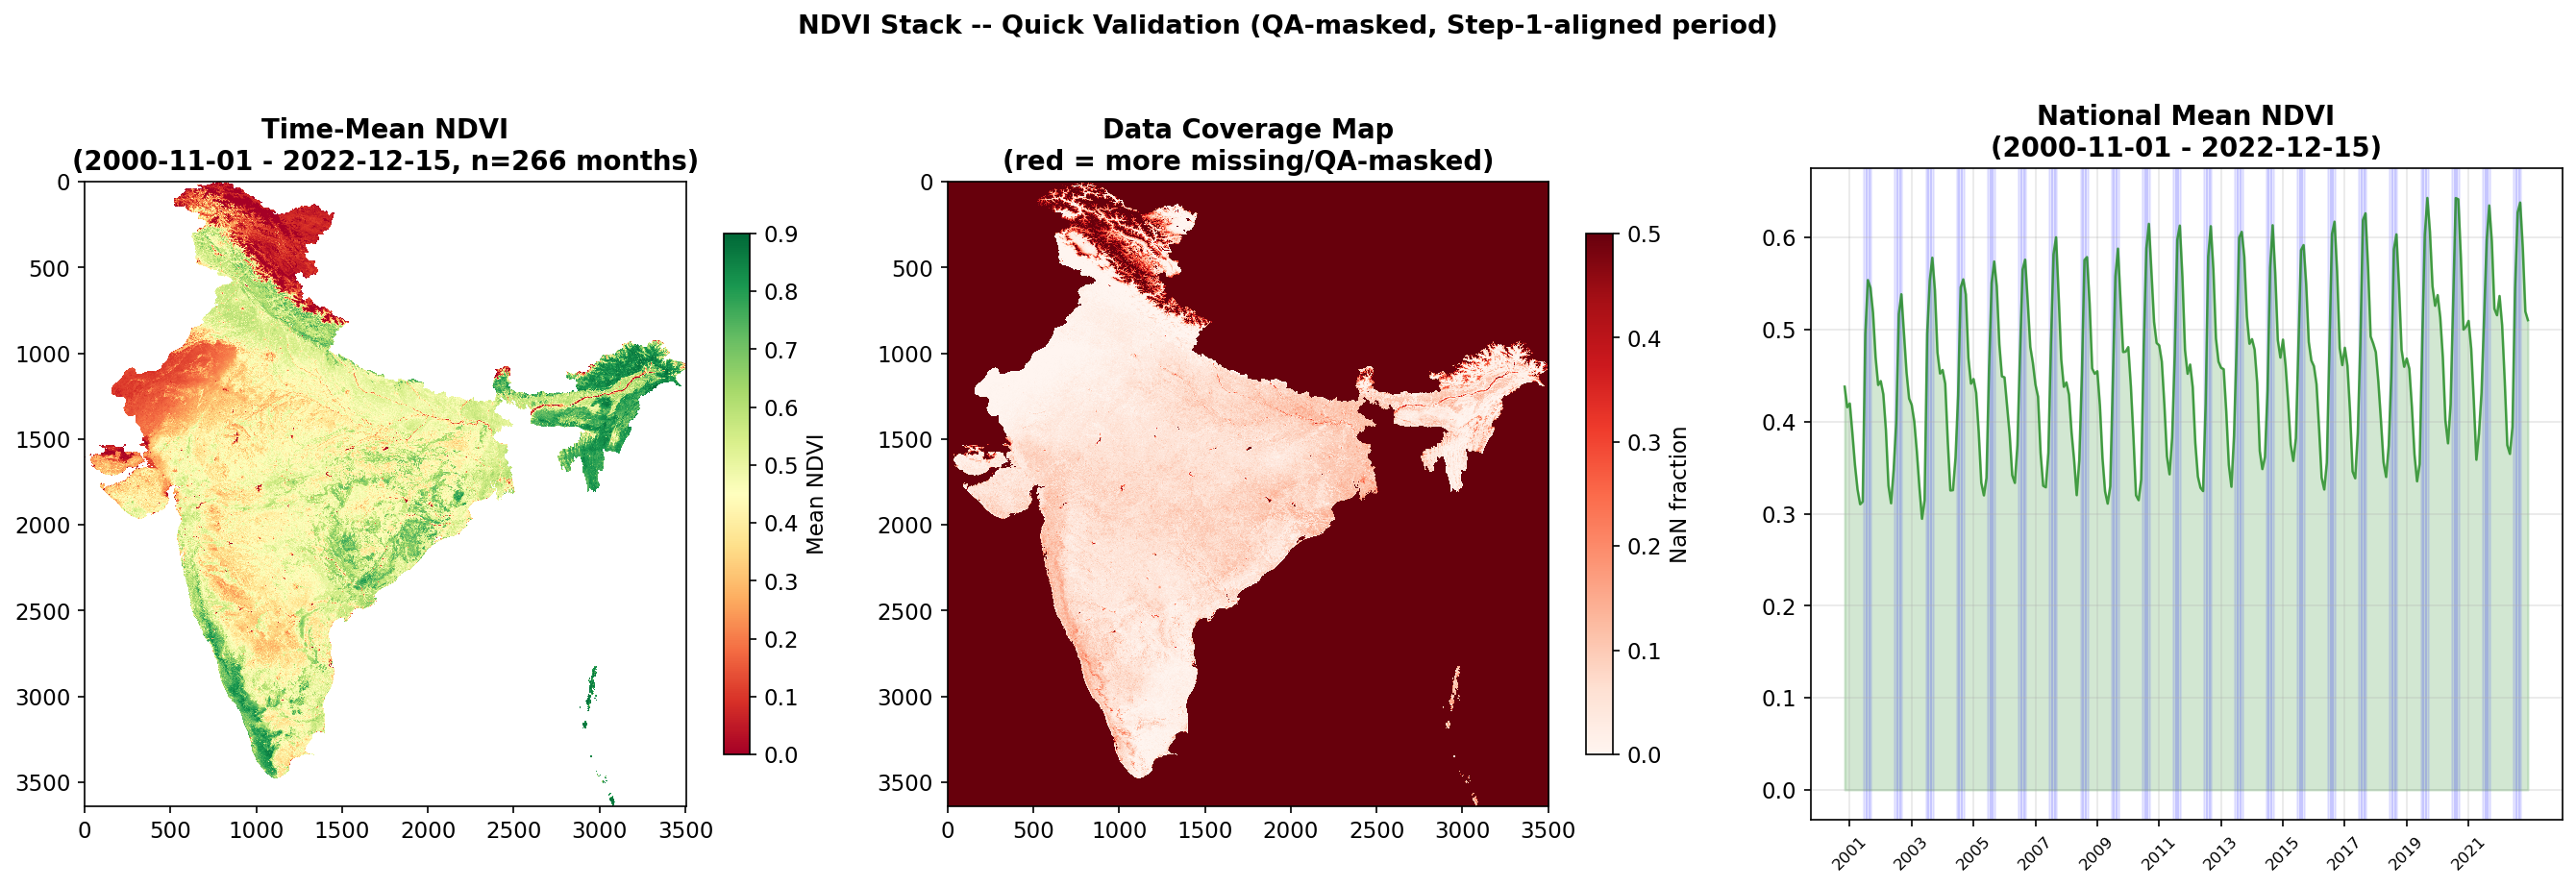

[OK] Validation plot saved to: D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\validation_plots.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ndvi_mean_map_preview = np.nanmean(ndvi_stack, axis=0)
im0 = axes[0].imshow(ndvi_mean_map_preview, cmap='RdYlGn', vmin=0.0, vmax=0.9, interpolation='nearest')
plt.colorbar(im0, ax=axes[0], label='Mean NDVI', shrink=0.8)
axes[0].set_title(f'Time-Mean NDVI\n({STUDY_START.date()} - {STUDY_END.date()}, n={T} months)', fontweight='bold')

nan_frac = np.mean(np.isnan(ndvi_stack), axis=0)
im1 = axes[1].imshow(nan_frac, cmap='Reds', vmin=0, vmax=0.5, interpolation='nearest')
plt.colorbar(im1, ax=axes[1], label='NaN fraction', shrink=0.8)
axes[1].set_title('Data Coverage Map\n(red = more missing/QA-masked)', fontweight='bold')

national_mean = np.nanmean(ndvi_stack.reshape(T, -1), axis=1)
ax = axes[2]
ax.plot(range(T), national_mean, color='forestgreen', lw=1.2, alpha=0.8)
ax.fill_between(range(T), national_mean, alpha=0.2, color='forestgreen')
tick_pos  = [i for i, (y, m) in enumerate(year_month_list) if m == 1]
tick_labs = [str(y) for y, m in year_month_list if m == 1]
ax.set_xticks(tick_pos[::2]); ax.set_xticklabels(tick_labs[::2], rotation=45, fontsize=8)
ax.set_title(f'National Mean NDVI\n({STUDY_START.date()} - {STUDY_END.date()})', fontweight='bold')
ax.grid(True, alpha=0.3)
for i, (y, m) in enumerate(year_month_list):
    if m in [7, 8, 9]:
        ax.axvspan(i-0.5, i+0.5, alpha=0.08, color='blue')

plt.suptitle('NDVI Stack -- Quick Validation (QA-masked, Step-1-aligned period)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'validation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] Validation plot saved to: {OUT_DIR / 'validation_plots.png'}")


## 🌦️ Step 5 — Feature 1 & 3: Climatological Mean & Monthly Anomaly (GPU)
Eq: μ̄ᵢⱼ⁽ᵐ⁾ = mean of NDVI(y,m) over the baseline years; δ = NDVI − μ̄.

Computing climatological mean & monthly anomaly (GPU)...


[OK] Anomaly computed


   Anomaly range : [-1.181, 1.167]


   Mean anomaly (should be approx 0): 0.0036


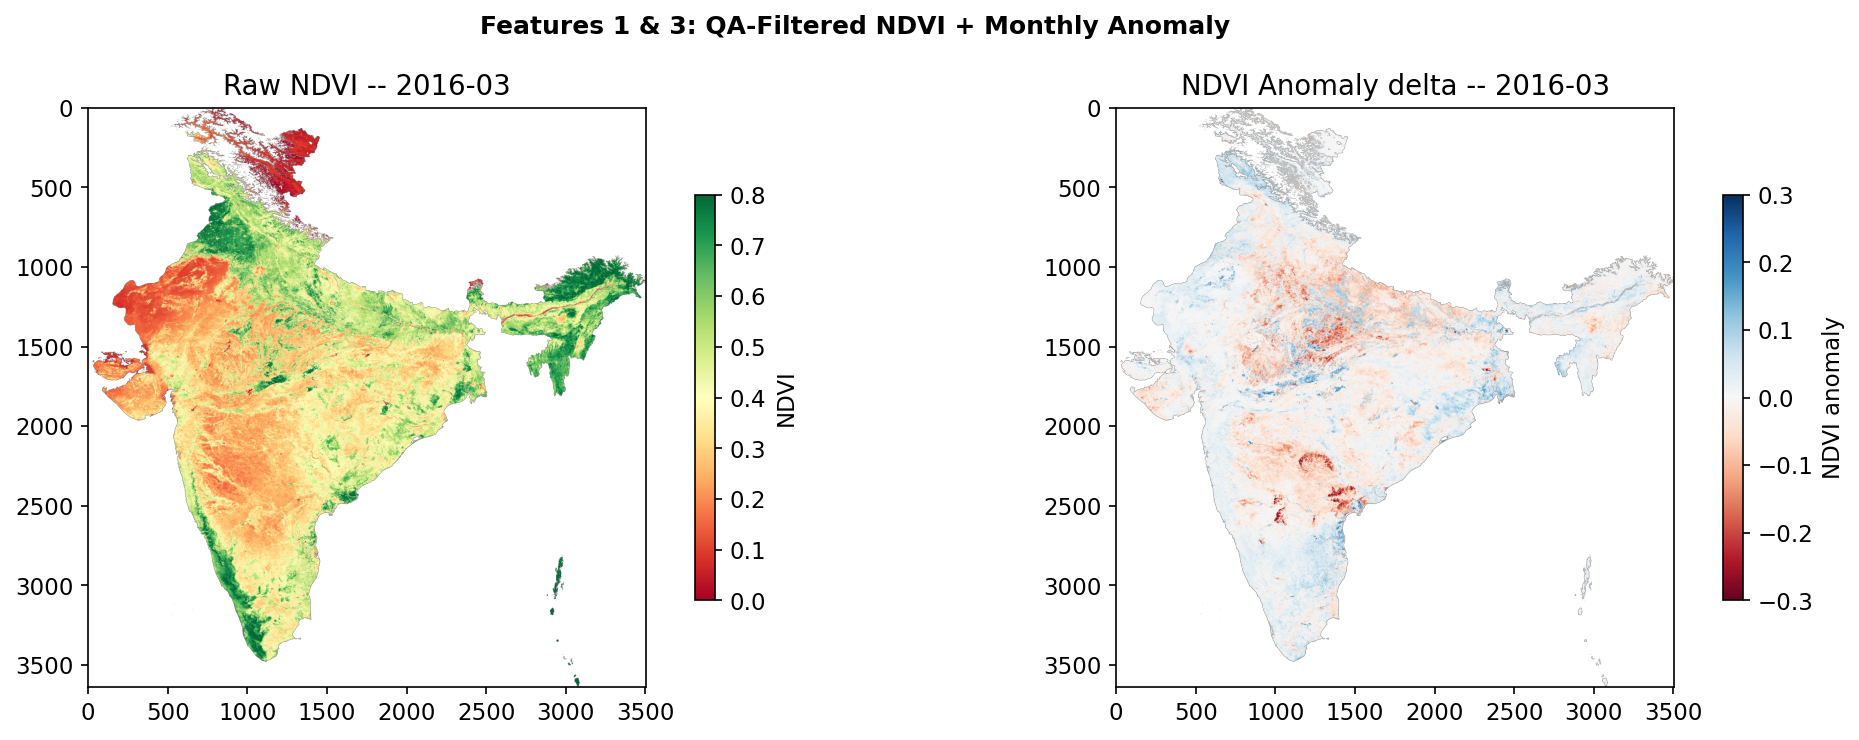

In [8]:
print("Computing climatological mean & monthly anomaly "
      + ("(GPU)..." if GPU_AVAILABLE else "(CPU)..."))

baseline_mask_np = (years_arr >= BASELINE_START) & (years_arr <= BASELINE_END)

stack_dev = cp.asarray(ndvi_stack)
baseline_mask_dev = cp.asarray(baseline_mask_np)
months_dev = cp.asarray(months_arr)

clim_mean_dev = cp.full((12, H, W), cp.nan, dtype=cp.float32)
for mo in range(1, 13):
    mo_mask = baseline_mask_dev & (months_dev == mo)
    if int(mo_mask.sum()) > 0:
        clim_mean_dev[mo-1] = cp.nanmean(stack_dev[mo_mask], axis=0)

anomaly_dev = cp.empty_like(stack_dev)
for t in range(T):
    anomaly_dev[t] = stack_dev[t] - clim_mean_dev[months_arr[t]-1]

ndvi_anomaly = to_host(anomaly_dev)
clim_mean = to_host(clim_mean_dev)

del stack_dev, anomaly_dev, baseline_mask_dev, months_dev, clim_mean_dev
free_gpu()

print('[OK] Anomaly computed')
print(f'   Anomaly range : [{np.nanmin(ndvi_anomaly):.3f}, {np.nanmax(ndvi_anomaly):.3f}]')
print(f'   Mean anomaly (should be approx 0): {np.nanmean(ndvi_anomaly):.4f}')

target = (2016, 3) if (2016, 3) in year_month_list else year_month_list[len(year_month_list)//2]
idx = year_month_list.index(target)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(ndvi_stack[idx], cmap='RdYlGn', vmin=0, vmax=0.8)
axes[0].set_title(f'Raw NDVI -- {target[0]}-{target[1]:02d}')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='NDVI')
im1 = axes[1].imshow(ndvi_anomaly[idx], cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[1].set_title(f'NDVI Anomaly delta -- {target[0]}-{target[1]:02d}')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='NDVI anomaly')
plt.suptitle('Features 1 & 3: QA-Filtered NDVI + Monthly Anomaly', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F1_F3_NDVI_Anomaly.png', dpi=150, bbox_inches='tight')
plt.show()


## 📈 Step 6 — Features 4, 5 & 6: GPU-Vectorized Trend/Seasonal/Residual + Mann-Kendall
Replaces the previous per-pixel `statsmodels.STL` + per-pixel `kendalltau`
loops (projected >9 hours, crashed at 6.7%) with two fully vectorized GPU
passes over the whole `(T,H,W)` array:

1. **Trend**: classical 2×12 centered moving average (standard additive
   decomposition trend-cycle estimate for monthly data).
2. **Seasonal**: climatological mean of the detrended series per calendar
   month. **Residual** = detrended − seasonal.
3. **Mann-Kendall**: the S-statistic Σ_{i<j} sign(xⱼ−xᵢ) is computed via an
   O(T) lag-sweep (`S = Σ_lag Σ_t sign(x[t+lag]-x[t])`) across the whole grid
   at once — algebraically identical to the full pairwise sum, but vectorized
   instead of called per-pixel.

Computing trend/seasonal/residual decomposition (GPU, vectorized)...
Method: classical 2x12 centered moving-average decomposition.


Trend (2x12-MA):   0%|          | 0/254 [00:00<?, ?it/s]

Trend (2x12-MA):  42%|████▏     | 106/254 [00:00<00:00, 953.76it/s]

Trend (2x12-MA):  80%|███████▉  | 202/254 [00:00<00:00, 198.96it/s]

Trend (2x12-MA):  98%|█████████▊| 249/254 [00:01<00:00, 166.90it/s]

...

Mann-Kendall (lag sweep):   0%|          | 1/265 [00:03<13:38,  3.10s/it]

Mann-Kendall (lag sweep):  37%|███▋      | 98/265 [02:25<04:07,  1.48s/it]

Mann-Kendall (lag sweep):  85%|████████▍ | 224/265 [03:47<00:38,  1.06it/s]

Mann-Kendall (lag sweep): 100%|██████████| 265/265 [03:47<00:00,  1.16it/s]

  Significant browning pixels : 147,206
  Significant greening pixels : 3,731,210


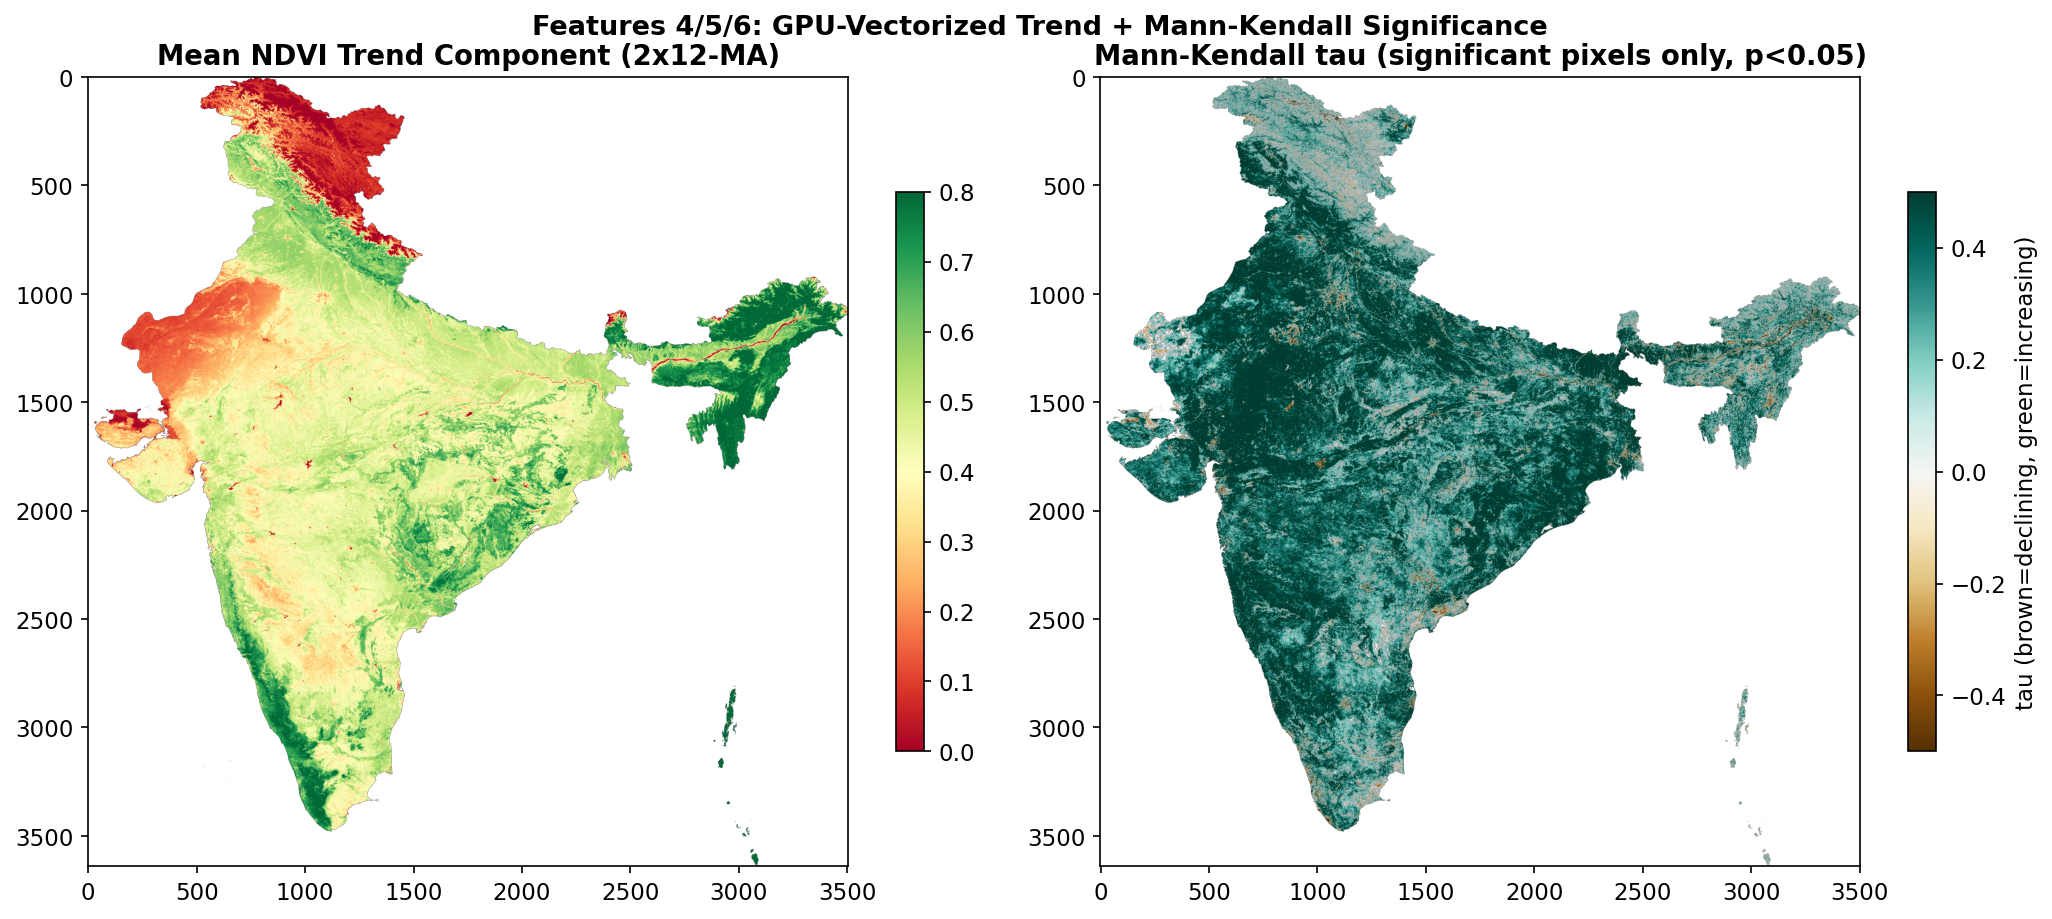

In [9]:
print("Computing trend/seasonal/residual decomposition (GPU, vectorized)...")
print("Method: classical 2x12 centered moving-average decomposition.")

stack_dev = cp.asarray(ndvi_stack)
period, half = 12, 6

trend_dev = cp.full_like(stack_dev, cp.nan)
weights_np = np.ones(period + 1, dtype=np.float32)
weights_np[0] = 0.5; weights_np[-1] = 0.5
weights_dev = cp.asarray(weights_np).reshape(-1, 1, 1)

for t in tqdm(range(half, T - half), desc="Trend (2x12-MA)"):
    window = stack_dev[t - half: t + half + 1]
    w = cp.where(cp.isnan(window), 0.0, weights_dev)
    wsum = w.sum(axis=0)
    num = cp.nansum(window * weights_dev, axis=0)
    trend_dev[t] = cp.where(wsum > 0, num / wsum, cp.nan)

stack_dev -= trend_dev              # in-place: stack_dev now holds "detrended"
detrended_dev = stack_dev
del stack_dev

months_dev = cp.asarray(months_arr)
seasonal_month_dev = cp.full((12, H, W), cp.nan, dtype=cp.float32)
for mo in range(1, 13):
    mo_mask = months_dev == mo
    seasonal_month_dev[mo-1] = cp.nanmean(detrended_dev[mo_mask], axis=0)

for t in range(T):
    detrended_dev[t] -= seasonal_month_dev[months_arr[t]-1]   # in-place -> now residual
residual_dev = detrended_dev
del detrended_dev

ndvi_residual_mean = to_host(cp.nanmean(residual_dev, axis=0))
ndvi_residual_std  = to_host(cp.nanstd(residual_dev, axis=0))
ndvi_trend_mean    = to_host(cp.nanmean(trend_dev, axis=0))
del residual_dev, seasonal_month_dev
free_gpu()
print('[OK] Decomposition complete')

# ── Mann-Kendall trend significance on the trend component (GPU) ──
print("\nComputing Mann-Kendall trend significance (GPU, vectorized lag-sweep)...")

S_dev = cp.zeros((H, W), dtype=cp.float32)
n_valid_dev = cp.sum(~cp.isnan(trend_dev), axis=0).astype(cp.float32)

for lag in tqdm(range(1, T), desc="Mann-Kendall (lag sweep)"):
    diff = trend_dev[lag:] - trend_dev[:-lag]
    S_dev += cp.nansum(cp.sign(diff), axis=0)
    del diff

var_s_dev = n_valid_dev * (n_valid_dev - 1) * (2 * n_valid_dev + 5) / 18.0
var_s_safe = cp.maximum(var_s_dev, 1e-9)
z_dev = cp.where(S_dev > 0, (S_dev - 1) / cp.sqrt(var_s_safe),
         cp.where(S_dev < 0, (S_dev + 1) / cp.sqrt(var_s_safe), 0.0))
p_dev = 2.0 * (1.0 - 0.5 * (1.0 + erf_fn(cp.abs(z_dev) / cp.sqrt(2.0))))
n_pairs_dev = cp.where(n_valid_dev > 1, n_valid_dev * (n_valid_dev - 1) / 2.0, cp.nan)
tau_dev = cp.where(n_pairs_dev > 0, S_dev / n_pairs_dev, cp.nan)
tau_dev = cp.where(n_valid_dev >= 10, tau_dev, cp.nan)
p_dev   = cp.where(n_valid_dev >= 10, p_dev, cp.nan)

mk_tau  = to_host(tau_dev)
mk_pval = to_host(p_dev)

del trend_dev, S_dev, n_valid_dev, var_s_dev, var_s_safe, z_dev, p_dev, n_pairs_dev, tau_dev, months_dev
free_gpu()

sig_mask     = mk_pval < 0.05
browning_sig = sig_mask & (mk_tau < 0)
greening_sig = sig_mask & (mk_tau > 0)
print(f'  Significant browning pixels : {np.sum(browning_sig):,}')
print(f'  Significant greening pixels : {np.sum(greening_sig):,}')

np.save(OUT_DIR / 'ndvi_trend_mean.npy', ndvi_trend_mean)
np.save(OUT_DIR / 'ndvi_mk_tau.npy', mk_tau)
np.save(OUT_DIR / 'ndvi_residual_mean.npy', ndvi_residual_mean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(ndvi_trend_mean, cmap='RdYlGn', vmin=0, vmax=0.8)
axes[0].set_title('Mean NDVI Trend Component (2x12-MA)', fontweight='bold')
plt.colorbar(im0, ax=axes[0], shrink=0.7)
trend_plot = np.where(sig_mask, mk_tau, np.nan)
im1 = axes[1].imshow(trend_plot, cmap='BrBG', vmin=-0.5, vmax=0.5)
axes[1].set_title('Mann-Kendall tau (significant pixels only, p<0.05)', fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='tau (brown=declining, green=increasing)')
plt.suptitle('Features 4/5/6: GPU-Vectorized Trend + Mann-Kendall Significance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F4_F6_Trend_MannKendall.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔥 Step 7 — Rasterize Step 1's Real Fire Points onto the NDVI Grid
This is the direct link to Step 1: every one of the 541,545 extracted
forest-fire points is mapped onto this notebook's NDVI grid using the same
exact affine-math pixel lookup Step 1 used for the LULC grid (not a nearest-
neighbour search). The result drives the real-data versions of F7 (CVSI) and
F9 (breakpoint threshold) below.

Rasterizing Step 1 forest-fire points onto the NDVI grid...
Loading: D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv
  Fire points loaded (Step 1 output): 541,545


  In NDVI grid bounds: 541,545  (excluded 0 outside the raster extent)
  With a matching NDVI month in 2000-11-01-2022-12-15: 541,545
  Distinct pixels with >=1 fire detection: 270,655 (2.12% of 12,758,064 pixels)


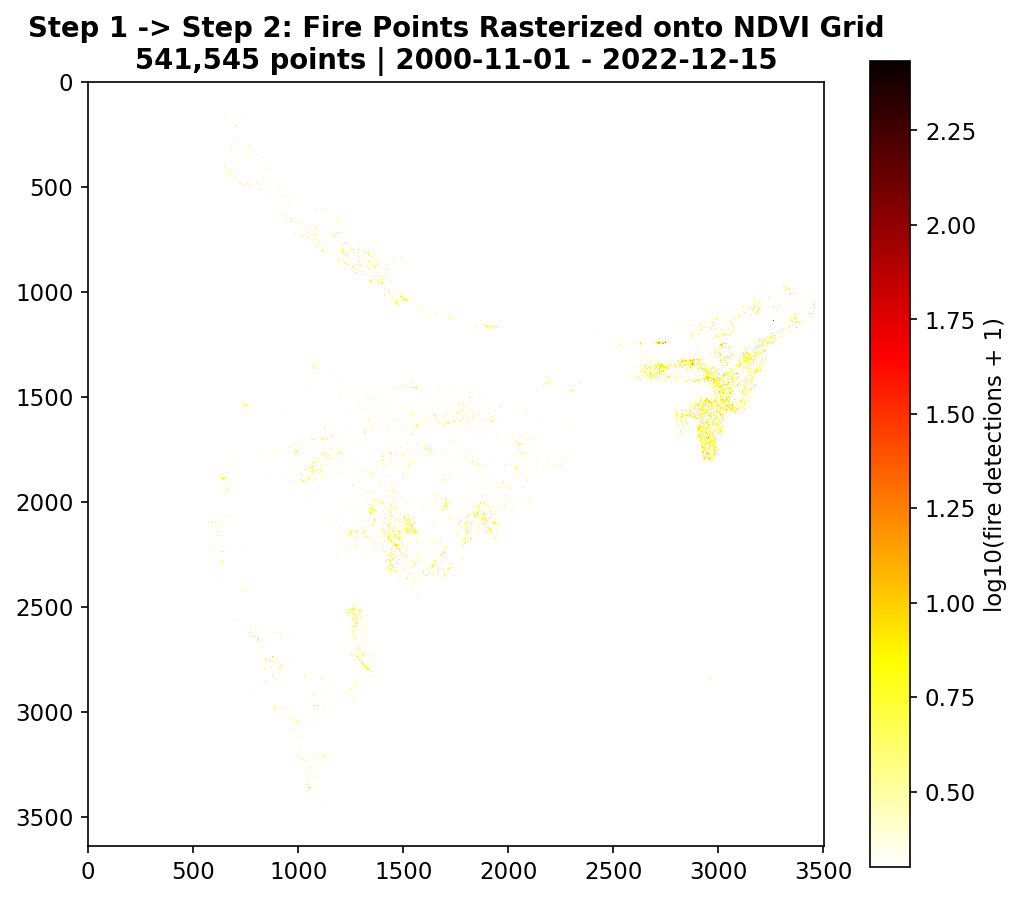

[OK] Fire rasterization complete -- drives F7 (CVSI) and F9 (breakpoint) below


In [10]:
print("Rasterizing Step 1 forest-fire points onto the NDVI grid...")
print(f"Loading: {FIRE_CSV}")

fire_df = pd.read_csv(FIRE_CSV, usecols=["latitude", "longitude", "acq_date", "year", "month"])
print(f"  Fire points loaded (Step 1 output): {len(fire_df):,}")

a, b, c, d, e, f = transform_ref[:6]   # affine coeffs; north-up grid so b=d=0
fire_row = np.round((fire_df["latitude"].values  - f) / e).astype(np.int64)
fire_col = np.round((fire_df["longitude"].values - c) / a).astype(np.int64)

in_bounds = (fire_row >= 0) & (fire_row < H) & (fire_col >= 0) & (fire_col < W)
n_out = int((~in_bounds).sum())
fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]
fire_year  = fire_df["year"].values[in_bounds]
fire_month = fire_df["month"].values[in_bounds]
print(f"  In NDVI grid bounds: {in_bounds.sum():,}  (excluded {n_out:,} outside the raster extent)")

ym_index = {ym: i for i, ym in enumerate(year_month_list)}
fire_t = np.array([ym_index.get((y, m), -1) for y, m in zip(fire_year, fire_month)])
has_month = fire_t >= 0
fire_row_m, fire_col_m, fire_t_m = fire_row[has_month], fire_col[has_month], fire_t[has_month]
print(f"  With a matching NDVI month in {STUDY_START.date()}-{STUDY_END.date()}: {has_month.sum():,}")

fire_count_map = np.zeros((H, W), dtype=np.int32)
np.add.at(fire_count_map, (fire_row, fire_col), 1)
fire_ever_mask = fire_count_map > 0
print(f"  Distinct pixels with >=1 fire detection: {int(fire_ever_mask.sum()):,} "
      f"({100*fire_ever_mask.mean():.2f}% of {H*W:,} pixels)")

np.save(OUT_DIR / 'fire_count_map.npy', fire_count_map)

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(np.where(fire_count_map > 0, np.log10(fire_count_map + 1), np.nan),
               cmap='hot_r', interpolation='nearest')
plt.colorbar(im, ax=ax, label='log10(fire detections + 1)', shrink=0.7)
ax.set_title(f'Step 1 -> Step 2: Fire Points Rasterized onto NDVI Grid\n'
             f'{len(fire_df):,} points | {STUDY_START.date()} - {STUDY_END.date()}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F10_fire_raster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Fire rasterization complete -- drives F7 (CVSI) and F9 (breakpoint) below')


## 🌡️ Step 8 — Feature 7: CVSI with a Real, Data-Driven Optimal Lag k\*
CVSI(t, k) = Σ_{lag=1}^{k} max(−δ_{t−lag}, 0) — accumulated pre-fire NDVI
deficit. k\* is chosen by maximizing **mutual information between CVSI values
and real fire occurrence** (Step 1 points vs. a balanced random background of
never-burned pixels), not a variance proxy.

Selecting optimal CVSI lag k via mutual information with real Step 1 fire occurrence...


  k=1: n_fire=540,292  n_bg=540,292  MI=0.00152


  k=2: n_fire=540,242  n_bg=540,242  MI=0.00049


  k=3: n_fire=540,012  n_bg=540,012  MI=0.00100


  k=4: n_fire=538,723  n_bg=538,723  MI=0.00333


...

  k=8: n_fire=534,461  n_bg=534,461  MI=0.01257


  k=9: n_fire=534,464  n_bg=534,464  MI=0.01036


  k=10: n_fire=534,440  n_bg=534,440  MI=0.00936


  k=11: n_fire=534,441  n_bg=534,441  MI=0.00831


  k=12: n_fire=534,424  n_bg=534,424  MI=0.00739

* Optimal lag k* = 8 months (mutual information with real fire occurrence)


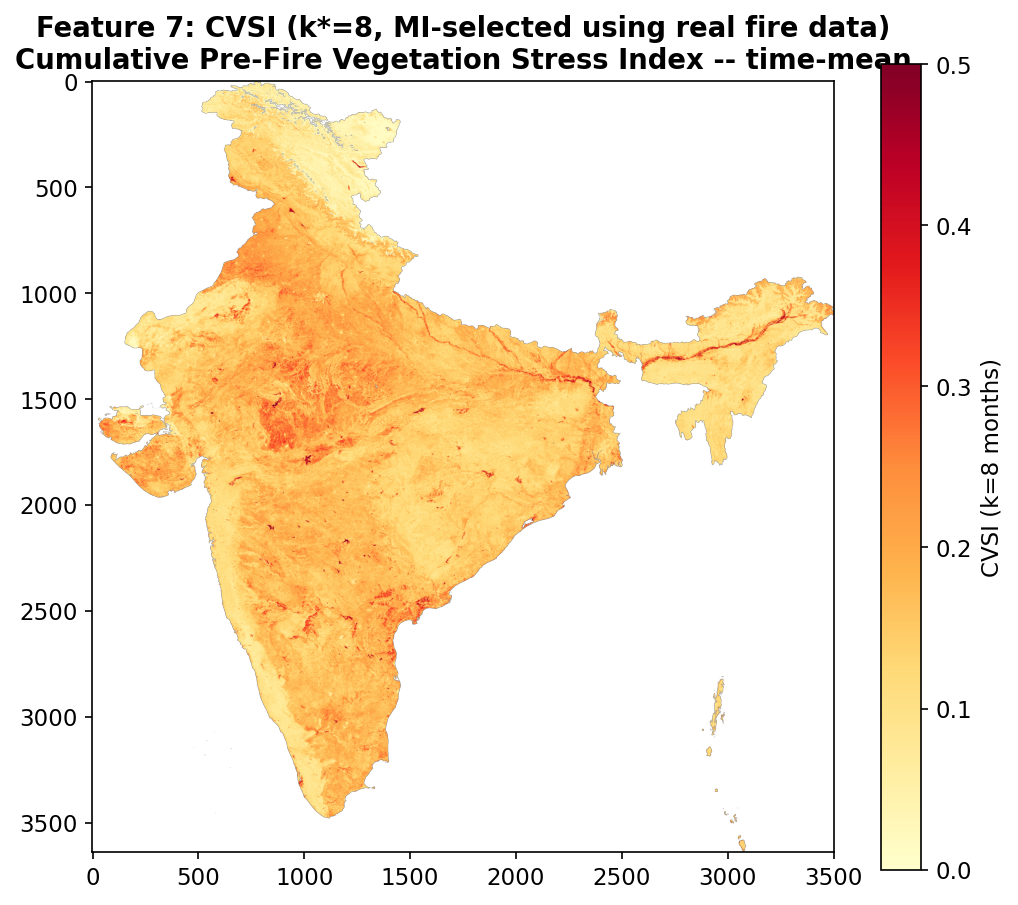

[OK] CVSI saved (k*=8)


In [11]:
def compute_cvsi_gpu(anomaly_dev, k):
    T_, H_, W_ = anomaly_dev.shape
    cvsi = cp.full((T_, H_, W_), cp.nan, dtype=cp.float32)
    for t in range(k, T_):
        window = anomaly_dev[t-k:t]
        stress = cp.where(window < 0, -window, 0.0)
        valid  = ~cp.isnan(window)
        cvsi[t] = cp.where(valid.sum(axis=0) >= max(1, k // 2), cp.nansum(stress, axis=0), cp.nan)
    return cvsi


print("Selecting optimal CVSI lag k via mutual information with real Step 1 fire occurrence...")

anomaly_dev = cp.asarray(ndvi_anomaly)
rng = np.random.RandomState(42)
mi_scores = {}

for k in range(1, 13):
    cvsi_k_dev = compute_cvsi_gpu(anomaly_dev, k)
    cvsi_k = to_host(cvsi_k_dev)
    del cvsi_k_dev
    free_gpu()

    valid_fire = fire_t_m >= k
    t_f, r_f, c_f = fire_t_m[valid_fire], fire_row_m[valid_fire], fire_col_m[valid_fire]
    pos_vals = cvsi_k[t_f, r_f, c_f]
    pos_vals = pos_vals[~np.isnan(pos_vals)]
    n_pos = len(pos_vals)

    valid_t, valid_r, valid_c = np.where(~np.isnan(cvsi_k))
    not_fire_pixel = ~fire_ever_mask[valid_r, valid_c]
    valid_t, valid_r, valid_c = valid_t[not_fire_pixel], valid_r[not_fire_pixel], valid_c[not_fire_pixel]
    n_bg = min(n_pos, len(valid_t)) if n_pos > 0 else 0
    if n_bg > 0:
        sel = rng.choice(len(valid_t), size=n_bg, replace=False)
        neg_vals = cvsi_k[valid_t[sel], valid_r[sel], valid_c[sel]]
    else:
        neg_vals = np.array([])

    if n_pos >= 50 and n_bg >= 50:
        x = np.concatenate([pos_vals, neg_vals]).reshape(-1, 1)
        y = np.concatenate([np.ones(n_pos), np.zeros(n_bg)])
        kb = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
        x_binned = kb.fit_transform(x).ravel()
        mi_scores[k] = mutual_info_score(y, x_binned)
    else:
        mi_scores[k] = np.nan
    del cvsi_k
    print(f"  k={k}: n_fire={n_pos:,}  n_bg={n_bg:,}  MI={mi_scores[k]:.5f}")

k_star = max((k for k in mi_scores if not np.isnan(mi_scores[k])), key=lambda k: mi_scores[k])
print(f"\n* Optimal lag k* = {k_star} months (mutual information with real fire occurrence)")

cvsi_optimal_dev = compute_cvsi_gpu(anomaly_dev, k_star)
cvsi_optimal = to_host(cvsi_optimal_dev)
del cvsi_optimal_dev, anomaly_dev
free_gpu()

cvsi_mean_map = np.nanmean(cvsi_optimal, axis=0)
np.save(OUT_DIR / f'cvsi_k{k_star}_mean.npy', cvsi_mean_map)

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(cvsi_mean_map, cmap='YlOrRd', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label=f'CVSI (k={k_star} months)', shrink=0.7)
ax.set_title(f'Feature 7: CVSI (k*={k_star}, MI-selected using real fire data)\n'
             f'Cumulative Pre-Fire Vegetation Stress Index -- time-mean', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'F7_CVSI_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] CVSI saved (k*={k_star})')


## 🗺️ Step 9 — Feature 8: Global Moran's I + Local LISA Cluster Map
CPU (`esda`/`libpysal` use Numba internally, not GPU-portable). Ocean/no-data
pixels are filled with the row-wise land mean before Moran's I (NaN-safe),
and arrays are cast to `float64` (`esda`'s Numba kernels require it).

Computing spatial autocorrelation (Moran's I)...


  Full grid size    : 3641 x 3504 = 12,758,064 pixels
  Valid land pixels : 4,161,009
  Coarsened grid    : 456 x 438 = 199,728 pixels (stride=8)
  NaN after fill    : 0  (filled 134,711 ocean/no-data pixels)


  Weight matrix     : n=199,728  pct_nonzero=0.00%



-- Global Moran's I --
  I       = 0.8322
  z-score = 742.105
  p-value = 0.0000

Computing Local Moran's I (LISA, 199 permutations)...



-- LISA cluster counts (p<0.05) --
  Ocean / No Data                              : 134,711  (67.4%)
  Not Significant                              :  42,077  (21.1%)
  High-High (HH): Dense forest cluster         :  13,412  (6.7%)
  Low-High (LH): Sparse in dense neighbourhood :     197  (0.1%)
  Low-Low (LL): Sparse/degraded forest         :   9,254  (4.6%)
  High-Low (HL): Forest fragment (WUI risk)    :      77  (0.0%)


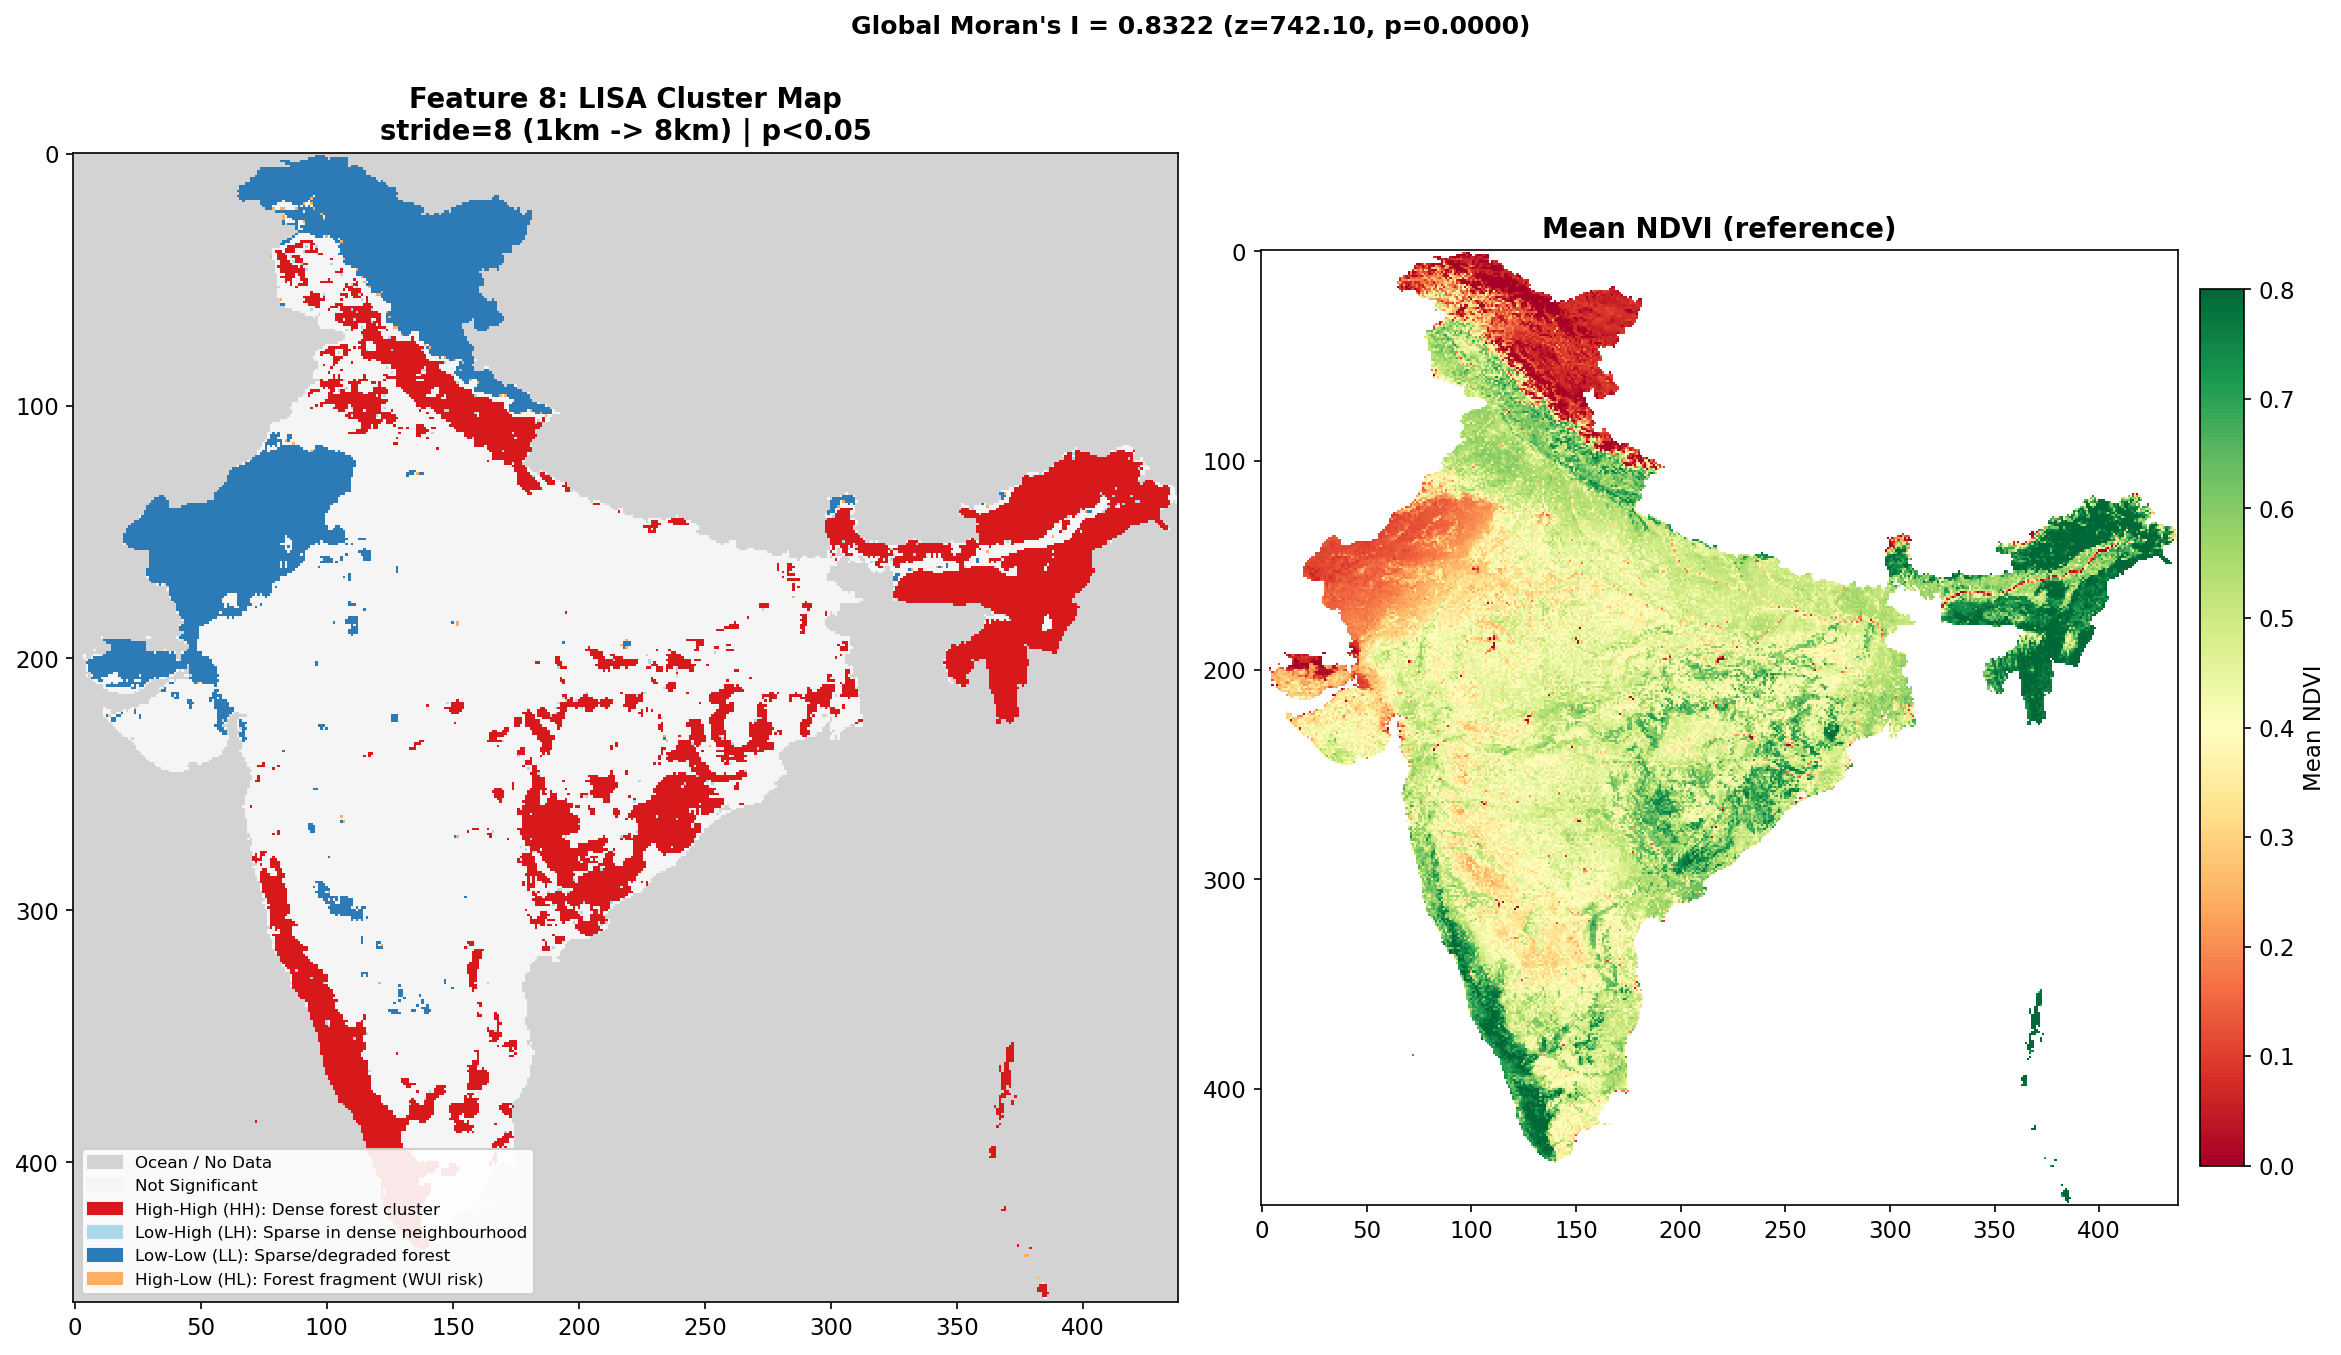

[OK] Moran's I / LISA complete


In [12]:
print("Computing spatial autocorrelation (Moran's I)...")

ndvi_mean_map = np.nanmean(ndvi_stack, axis=0)
print(f'  Full grid size    : {H} x {W} = {H*W:,} pixels')
print(f'  Valid land pixels : {np.sum(~np.isnan(ndvi_mean_map)):,}')

stride = 8   # coarsen 1km -> 8km for a tractable LISA grid
ndvi_coarse = ndvi_mean_map[::stride, ::stride].copy()
Hc, Wc = ndvi_coarse.shape
print(f'  Coarsened grid    : {Hc} x {Wc} = {Hc*Wc:,} pixels (stride={stride})')

ndvi_coarse_filled = ndvi_coarse.copy().astype(np.float64)
valid_mask_2d = ~np.isnan(ndvi_coarse)
for row in range(Hc):
    row_vals = ndvi_coarse_filled[row, valid_mask_2d[row]]
    row_mean = row_vals.mean() if len(row_vals) > 0 else 0.0
    ndvi_coarse_filled[row, ~valid_mask_2d[row]] = row_mean
assert np.sum(np.isnan(ndvi_coarse_filled)) == 0
print(f'  NaN after fill    : 0  (filled {np.sum(~valid_mask_2d):,} ocean/no-data pixels)')

w_lattice = lat2W(Hc, Wc, rook=False)
w_lattice.transform = 'R'
print(f'  Weight matrix     : n={w_lattice.n:,}  pct_nonzero={w_lattice.pct_nonzero:.2f}%')

y_flat = ndvi_coarse_filled.flatten().astype(np.float64)
moran_global = Moran(y_flat, w_lattice, permutations=0)
print(f'\n-- Global Moran\'s I --')
print(f'  I       = {moran_global.I:.4f}')
print(f'  z-score = {moran_global.z_norm:.3f}')
print(f'  p-value = {moran_global.p_norm:.4f}')

print("\nComputing Local Moran's I (LISA, 199 permutations)...")
moran_local = Moran_Local(y_flat, w_lattice, transformation='R', permutations=199, n_jobs=-1, seed=42)

lisa_q = moran_local.q.reshape(Hc, Wc).astype(float)
lisa_p = moran_local.p_sim.reshape(Hc, Wc)
lisa_sig = np.where(lisa_p < 0.05, lisa_q, 0).astype(float)
lisa_sig[~valid_mask_2d] = -1

colors = {-1: '#D3D3D3', 0: '#F5F5F5', 1: '#d7191c', 2: '#abd9e9', 3: '#2c7bb6', 4: '#fdae61'}
labels = {-1: 'Ocean / No Data', 0: 'Not Significant',
          1: 'High-High (HH): Dense forest cluster',
          2: 'Low-High (LH): Sparse in dense neighbourhood',
          3: 'Low-Low (LL): Sparse/degraded forest',
          4: 'High-Low (HL): Forest fragment (WUI risk)'}

print('\n-- LISA cluster counts (p<0.05) --')
for q, lbl in labels.items():
    count = int(np.sum(lisa_sig == q))
    print(f'  {lbl:<45s}: {count:>7,}  ({100*count/(Hc*Wc):.1f}%)')

sorted_keys = sorted(colors.keys())
cmap = mcolors.ListedColormap([colors[k] for k in sorted_keys])
bounds = [k - 0.5 for k in sorted_keys] + [sorted_keys[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].imshow(lisa_sig, cmap=cmap, norm=norm, interpolation='nearest', origin='upper')
axes[0].legend(handles=[Patch(color=colors[k], label=labels[k]) for k in sorted_keys],
               loc='lower left', fontsize=8, framealpha=0.9)
axes[0].set_title(f'Feature 8: LISA Cluster Map\nstride={stride} (1km -> {stride}km) | p<0.05', fontweight='bold')

im2 = axes[1].imshow(ndvi_coarse, cmap='RdYlGn', vmin=0.0, vmax=0.8, interpolation='nearest', origin='upper')
plt.colorbar(im2, ax=axes[1], label='Mean NDVI', shrink=0.7, pad=0.02)
axes[1].set_title('Mean NDVI (reference)', fontweight='bold')

plt.suptitle(f"Global Moran's I = {moran_global.I:.4f} (z={moran_global.z_norm:.2f}, p={moran_global.p_norm:.4f})",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'F8_LISA_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] Moran\'s I / LISA complete')


## 🎯 Step 10 — Feature 9: NDVI–Fire Breakpoint Threshold (Real Labels)
Piecewise logistic regression fit against **real fire/no-fire pixel labels**
(from Step 7's rasterization), nationally and per biogeographic zone, using a
balanced case-control subsample for tractable optimization.

Fitting NDVI-fire breakpoint threshold (piecewise logistic) using real Step 1 labels...


  All India           : theta* = 0.535  (n=200,000: 100,000 fire / 100,000 no-fire)

Zone-stratified breakpoint thresholds (real biogeographic zones):


  Western_Ghats       : theta* = 0.484  (n=116,335: 16,335 fire / 100,000 no-fire)  [11/25 starts degenerate, excluded]


  Northeast           : theta* = 0.643  (n=200,000: 100,000 fire / 100,000 no-fire)


  Himalayan           : theta* = 0.530  (n=127,007: 27,007 fire / 100,000 no-fire)


  Central_India       : theta* = 0.506  (n=181,298: 81,298 fire / 100,000 no-fire)


  Deccan              : theta* = 0.498  (n=118,954: 18,954 fire / 100,000 no-fire)  [5/25 starts degenerate, excluded]

Zone threshold summary: {'Western_Ghats': np.float64(0.484), 'Northeast': np.float64(0.643), 'Himalayan': np.float64(0.53), 'Central_India': np.float64(0.506), 'Deccan': np.float64(0.498)}


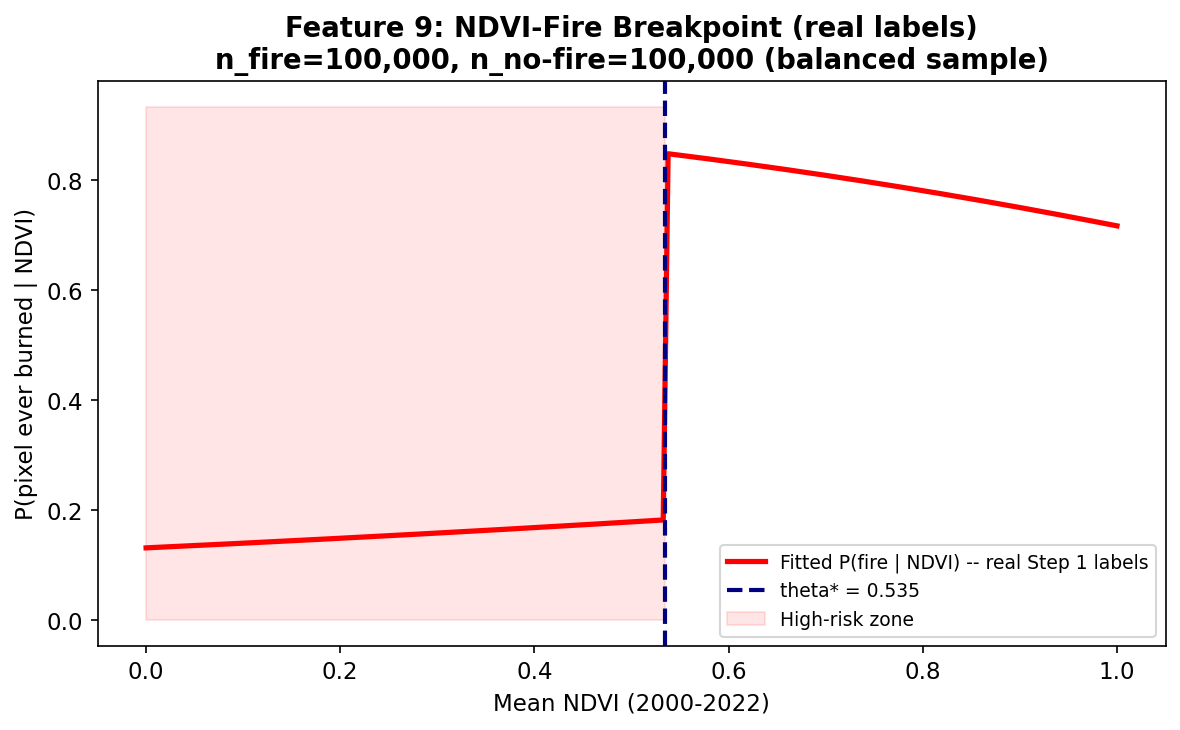


[OK] Breakpoint analysis complete (national + zone-stratified, real labels)


In [13]:
print("Fitting NDVI-fire breakpoint threshold (piecewise logistic) using real Step 1 labels...")

def piecewise_logistic_nll(params, x, y):
    a1, b1, a2, b2, theta = params
    prob = np.where(x <= theta, expit(a1 + b1*x), expit(a2 + b2*x))
    prob = np.clip(prob, 1e-7, 1 - 1e-7)
    return -np.sum(y*np.log(prob) + (1-y)*np.log(1-prob))


def find_ndvi_threshold(ndvi_vals, fire_labels, zone_name='All India', n_theta=25, max_n=200_000, seed=42,
                         degenerate_floor=0.01):
    # Fit a piecewise-logistic P(fire|NDVI) breakpoint theta* via multi-start Nelder-Mead.
    # theta is bounded to the physically valid NDVI range [NDVI_VALID_MIN, NDVI_VALID_MAX] so the
    # optimizer can never wander outside it regardless of which start it came from. In addition, any
    # winning solution where one regime (x<=theta or x>theta) holds fewer than degenerate_floor
    # (default 1%) of the sample is a boundary regime-collapse -- the piecewise model has effectively
    # become a single logistic and theta is not identifiable (the NLL surface is flat over a wide
    # theta range). Such solutions are excluded from consideration; if every one of the n_theta
    # starts degenerates this way, no numeric threshold is reported for this zone.
    valid = ~np.isnan(ndvi_vals)
    x, y = ndvi_vals[valid], fire_labels[valid]
    if len(x) < 200 or y.sum() < 30:
        print(f'  [!!] Insufficient data for {zone_name} (n={len(x):,}, fires={int(y.sum()):,})')
        return None, None, None

    rng = np.random.RandomState(seed)
    pos_idx, neg_idx = np.where(y == 1)[0], np.where(y == 0)[0]
    n_pos = min(len(pos_idx), max_n // 2)
    n_neg = min(len(neg_idx), max_n // 2)
    idx = np.concatenate([rng.choice(pos_idx, n_pos, replace=False),
                           rng.choice(neg_idx, n_neg, replace=False)])
    xs, ys = x[idx], y[idx]

    theta_grid = np.linspace(np.percentile(xs, 10), np.percentile(xs, 90), n_theta)
    # theta must stay within the physically valid NDVI range; the other 4 params (logistic
    # intercepts/slopes for each regime) are left unbounded.
    param_bounds = [(None, None), (None, None), (None, None), (None, None),
                     (NDVI_VALID_MIN, NDVI_VALID_MAX)]
    n_total = len(xs)
    floor_n = max(1, int(degenerate_floor * n_total))

    best_nll, best_theta, best_params = np.inf, None, None
    best_nll_any, best_theta_any = np.inf, None
    n_degenerate, n_attempted = 0, 0
    for theta_init in theta_grid:
        try:
            res = minimize(piecewise_logistic_nll, [0., -1., 0., -0.5, theta_init], args=(xs, ys),
                            method='Nelder-Mead', bounds=param_bounds,
                            options={'maxiter': 500, 'xatol': 1e-4})
        except Exception:
            continue
        n_attempted += 1
        theta_res = res.x[4]
        n_below = int(np.sum(xs <= theta_res))
        n_above = n_total - n_below
        if res.fun < best_nll_any:
            best_nll_any, best_theta_any = res.fun, theta_res
        if n_below < floor_n or n_above < floor_n:
            n_degenerate += 1   # boundary regime-collapse -- theta not identifiable here, skip
            continue
        if res.fun < best_nll:
            best_nll, best_theta, best_params = res.fun, theta_res, res.x

    if best_theta is None:
        if best_theta_any is not None:
            print(f'  [!!] {zone_name:20s}: no stable interior breakpoint -- single-regime logistic '
                  f'dominates ({n_degenerate}/{n_attempted} starts degenerate; best degenerate-solution '
                  f'theta={best_theta_any:.3f} NOT reported -- NLL surface is flat/non-identifiable there)')
        else:
            print(f'  [!!] {zone_name:20s}: optimization failed for all {n_theta} starts')
        return None, None, (n_pos, n_neg)

    degeneracy_note = f'  [{n_degenerate}/{n_attempted} starts degenerate, excluded]' if n_degenerate else ''
    print(f'  {zone_name:20s}: theta* = {best_theta:.3f}  (n={len(xs):,}: {n_pos:,} fire / {n_neg:,} no-fire)'
          f'{degeneracy_note}')
    return best_theta, best_params, (n_pos, n_neg)


fire_label_map = fire_ever_mask.astype(np.int8)
theta_india, params_india, n_india = find_ndvi_threshold(ndvi_mean_map.flatten(), fire_label_map.flatten(), 'All India')

lon0, lat0 = c + a * 0.5, f + e * 0.5
lons_1d = lon0 + a * np.arange(W)
lats_1d = lat0 + e * np.arange(H)
lon_grid, lat_grid = np.meshgrid(lons_1d, lats_1d)

zone_thresholds = {}
print('\nZone-stratified breakpoint thresholds (real biogeographic zones):')
for zone, bbox in BIO_ZONES.items():
    zmask = ((lon_grid >= bbox['lon_min']) & (lon_grid <= bbox['lon_max']) &
             (lat_grid >= bbox['lat_min']) & (lat_grid <= bbox['lat_max']))
    theta_z, _, _ = find_ndvi_threshold(ndvi_mean_map[zmask], fire_label_map[zmask], zone)
    # Store NaN (not a fabricated number) for zones with no stable interior breakpoint, so the
    # degeneracy is explicit in the results table rather than silently missing an entry.
    zone_thresholds[zone] = round(theta_z, 3) if theta_z is not None else np.nan

print('\nZone threshold summary:', zone_thresholds)

if theta_india is not None:
    a1, b1, a2, b2, _ = params_india
    ndvi_range = np.linspace(0, 1, 200)
    p_piece = np.where(ndvi_range <= theta_india, expit(a1 + b1*ndvi_range), expit(a2 + b2*ndvi_range))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ndvi_range, p_piece, 'r-', lw=2.5, label='Fitted P(fire | NDVI) -- real Step 1 labels')
    ax.axvline(theta_india, color='navy', ls='--', lw=2, label=f'theta* = {theta_india:.3f}')
    ax.fill_betweenx([0, max(p_piece)*1.1], 0, theta_india, alpha=0.1, color='red', label='High-risk zone')
    ax.set_xlabel('Mean NDVI (2000-2022)'); ax.set_ylabel('P(pixel ever burned | NDVI)')
    ax.set_title(f'Feature 9: NDVI-Fire Breakpoint (real labels)\n'
                 f'n_fire={n_india[0]:,}, n_no-fire={n_india[1]:,} (balanced sample)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'F9_NDVI_breakpoint.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n[OK] Breakpoint analysis complete (national + zone-stratified, real labels)')


## 💾 Step 11 — Feature Compilation & GeoTIFF Export
Saves all 10 features (9 NDVI-derived + the Step 1 fire raster) as GeoTIFFs
for the downstream ML pipeline.

In [14]:
def save_feature_geotiff(array_2d, feature_name, meta, out_dir):
    out_path = out_dir / f'{feature_name}.tif'
    m = meta.copy()
    m.update({'count': 1, 'dtype': 'float32', 'nodata': np.nan, 'compress': 'lzw'})
    with rasterio.open(out_path, 'w', **m) as dst:
        dst.write(array_2d.astype(np.float32), 1)
        dst.update_tags(FEATURE=feature_name, SOURCE='MOD13A3.061',
                         PERIOD=f'{STUDY_START.date()} to {STUDY_END.date()}',
                         REFERENCE='Novel extension of Biswas et al. 2025, Step 2 (linked to Step 1 fire points)')
    print(f'  [OK] Saved: {feature_name}.tif')
    return out_path


print(f'Exporting all features as GeoTIFFs to {OUT_DIR}\n')
feature_paths = {}

feature_paths['F1'] = save_feature_geotiff(ndvi_mean_map, 'F1_NDVI_QA_mean', meta_ref, OUT_DIR)
feature_paths['F2'] = save_feature_geotiff(clim_mean[5], 'F2_NDVI_climatological_June', meta_ref, OUT_DIR)
feature_paths['F3'] = save_feature_geotiff(np.nanmean(ndvi_anomaly, axis=0), 'F3_NDVI_anomaly_mean', meta_ref, OUT_DIR)
feature_paths['F4'] = save_feature_geotiff(ndvi_trend_mean, 'F4_NDVI_trend_2x12MA', meta_ref, OUT_DIR)
feature_paths['F5'] = save_feature_geotiff(ndvi_residual_mean, 'F5_NDVI_residual_mean', meta_ref, OUT_DIR)
feature_paths['F6'] = save_feature_geotiff(mk_tau, 'F6_MannKendall_tau', meta_ref, OUT_DIR)
feature_paths['F7'] = save_feature_geotiff(cvsi_mean_map, f'F7_CVSI_k{k_star}', meta_ref, OUT_DIR)

lisa_upscaled = zoom(lisa_sig, stride, order=0)[:H, :W]
feature_paths['F8'] = save_feature_geotiff(lisa_upscaled.astype(np.float32), 'F8_LISA_cluster', meta_ref, OUT_DIR)

if theta_india is not None:
    # np.where keeps NaN (not False/0.0) at masked-out (outside-India / no-data) pixels --
    # a plain boolean cast would silently mislabel them as "not below threshold".
    ndvi_below_thresh = np.where(np.isnan(ndvi_mean_map), np.nan,
                                  (ndvi_mean_map < theta_india).astype(np.float32))
    feature_paths['F9'] = save_feature_geotiff(
        ndvi_below_thresh, f'F9_NDVI_below_threshold_{theta_india:.3f}', meta_ref, OUT_DIR)

feature_paths['F10'] = save_feature_geotiff(fire_count_map.astype(np.float32), 'F10_fire_count_Step1', meta_ref, OUT_DIR)

print(f'\n[OK] {len(feature_paths)} features exported to {OUT_DIR}')


Exporting all features as GeoTIFFs to D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs



  [OK] Saved: F1_NDVI_QA_mean.tif


  [OK] Saved: F2_NDVI_climatological_June.tif


  [OK] Saved: F3_NDVI_anomaly_mean.tif


  [OK] Saved: F4_NDVI_trend_2x12MA.tif


  [OK] Saved: F5_NDVI_residual_mean.tif


  [OK] Saved: F6_MannKendall_tau.tif


  [OK] Saved: F7_CVSI_k8.tif


  [OK] Saved: F8_LISA_cluster.tif


  [OK] Saved: F9_NDVI_below_threshold_0.535.tif
  [OK] Saved: F10_fire_count_Step1.tif

[OK] 10 features exported to D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs


## ✅ Step 12 — Summary: Novel Feature Comparison Table

In [15]:
print('='*70)
print('NDVI NOVEL FEATURE SUMMARY -- Step 2 (linked to Step 1)')
print('='*70)

summary = [
    ('F1', 'QA-Filtered NDVI mean',        'Genuinely QA-masked (fixed from previous version)'),
    ('F2', 'Climatological Monthly Mean',  'Seasonal baseline, 2001-2020'),
    ('F3', 'Monthly Anomaly delta',        'GPU-vectorized'),
    ('F4', 'Trend Component (2x12-MA)',    'GPU-vectorized -- full-res national decomposition'),
    ('F5', 'Residual Component',           'GPU-vectorized'),
    ('F6', 'Mann-Kendall tau',             'GPU lag-sweep -- full-res, not per-pixel loop'),
    ('F7', f'CVSI (k={k_star} months)',    'k* chosen via real mutual information with Step 1 fire points'),
    ('F8', 'LISA Cluster (Moran I_i)',     'Spatial neighbourhood, CPU (esda)'),
    ('F9', f'NDVI<theta* indicator',       f'theta*={theta_india:.3f}, fit on real Step 1 fire labels' if theta_india else 'n/a'),
    ('F10', 'Fire occurrence raster',      'Step 1 points rasterized onto this NDVI grid'),
]

print(f'{"#":<5} {"Feature":<32} {"Status"}')
print('-'*70)
for fid, name, status in summary:
    print(f'{fid:<5} {name:<32} {status}')

print('='*70)
print(f'Study period       : {STUDY_START.date()} -> {STUDY_END.date()}  (matches Step 1)')
print(f'Compute            : {"GPU (" + gpu_name + ")" if GPU_AVAILABLE else "CPU (NumPy fallback)"}')
print(f'Fire points used   : {len(fire_df):,}  (Step 1 real extraction, not synthetic)')
print(f'Pixels ever burned : {int(fire_ever_mask.sum()):,}  ({100*fire_ever_mask.mean():.2f}% of grid)')
print(f'Outputs            : {OUT_DIR}')
print('='*70)


NDVI NOVEL FEATURE SUMMARY -- Step 2 (linked to Step 1)
#     Feature                          Status
----------------------------------------------------------------------
F1    QA-Filtered NDVI mean            Genuinely QA-masked (fixed from previous version)
F2    Climatological Monthly Mean      Seasonal baseline, 2001-2020
F3    Monthly Anomaly delta            GPU-vectorized
F4    Trend Component (2x12-MA)        GPU-vectorized -- full-res national decomposition
F5    Residual Component               GPU-vectorized
F6    Mann-Kendall tau                 GPU lag-sweep -- full-res, not per-pixel loop
F7    CVSI (k=8 months)                k* chosen via real mutual information with Step 1 fire points
F8    LISA Cluster (Moran I_i)         Spatial neighbourhood, CPU (esda)
F9    NDVI<theta* indicator            theta*=0.535, fit on real Step 1 fire labels
F10   Fire occurrence raster           Step 1 points rasterized onto this NDVI grid
Study period       : 2000-11-01 -> 2022-12-15 